In [1]:
from temporaldata import Data
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
path = "/home/mila/s/sobralm/auditorydecoding/data/processed/neurosoft_minipigs_2026/sub-03_ses-04_task-AcousStim_acq-LHanest_desc-raw.h5"

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

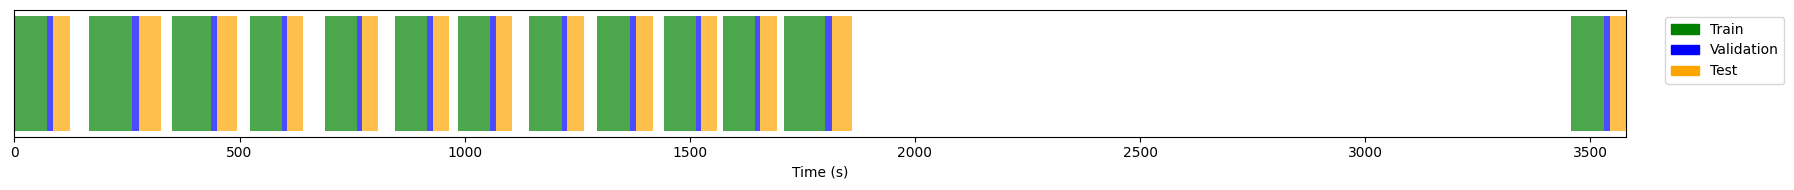

In [3]:
train_splits = data.splits.on_vs_off_causal_train
valid_splits = data.splits.on_vs_off_causal_valid
test_splits = data.splits.on_vs_off_causal_test

# Plot the interval of each split
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(18, 2))

y = 0

# Plot train intervals (green)
for start, end in zip(train_splits.start, train_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="green", alpha=0.7)

# Plot valid intervals (blue)
for start, end in zip(valid_splits.start, valid_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="blue", alpha=0.7)

# Plot test intervals (orange)
for start, end in zip(test_splits.start, test_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="orange", alpha=0.7)

ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_xlim(
    [
        min(
            train_splits.start.min(),
            valid_splits.start.min(),
            test_splits.start.min(),
        ),
        max(
            train_splits.end.max(),
            valid_splits.end.max(),
            test_splits.end.max(),
        ),
    ]
)

# Make legend
legend_handles = [
    mpatches.Patch(color="green", label="Train"),
    mpatches.Patch(color="blue", label="Validation"),
    mpatches.Patch(color="orange", label="Test"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [4]:
np.unique(train_splits.recording_id, return_counts=True)

(array([b'sub-03_ses-04_task-AcousticStim_acq-L10kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L15kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L1kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L20kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L2kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L500Hzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L5kHzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L5kHzanest_run-2_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-L800Hzanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-LBaselineanest_run-1_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-LBaselineanest_run-2_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-LBaselineanest_run-3_desc-raw',
        b'sub-03_ses-04_task-AcousticStim_acq-LWhiteNoiseanest_run-1_desc-raw'],
       dtype=o

In [5]:
mask = (
    train_splits.recording_id
    == b"sub-03_ses-04_task-AcousticStim_acq-LWhiteNoiseanest_run-1_desc-raw"
)
intervals = train_splits.select_by_mask(mask)

In [6]:
intervals.start

array([1574.155, 1574.655, 1575.155, 1575.655, 1576.155, 1576.655,
       1577.155, 1577.655, 1578.155, 1578.655, 1579.155, 1579.655,
       1580.155, 1580.655, 1581.155, 1581.655, 1582.155, 1582.655,
       1583.155, 1583.655, 1584.155, 1584.655, 1585.155, 1585.655,
       1586.155, 1586.655, 1587.155, 1587.655, 1588.155, 1588.655,
       1589.155, 1589.655, 1590.155, 1590.655, 1591.155, 1591.655,
       1592.155, 1592.655, 1593.155, 1593.655, 1594.155, 1594.655,
       1595.155, 1595.655, 1596.155, 1596.655, 1597.155, 1597.655,
       1598.155, 1598.655, 1599.155, 1599.655, 1600.155, 1600.655,
       1601.155, 1601.655, 1602.155, 1602.655, 1603.155, 1603.655,
       1604.155, 1604.655, 1605.155, 1605.655, 1606.155, 1606.655,
       1607.155, 1607.655, 1608.155, 1608.655, 1609.155, 1609.655,
       1610.155, 1610.655, 1611.155, 1611.655, 1612.155, 1612.655,
       1613.155, 1613.655, 1614.155, 1614.655, 1615.155, 1615.655,
       1616.155, 1616.655, 1617.155, 1617.655, 1618.155, 1618.

In [7]:
intervals.end

array([1574.655, 1575.155, 1575.655, 1576.155, 1576.655, 1577.155,
       1577.655, 1578.155, 1578.655, 1579.155, 1579.655, 1580.155,
       1580.655, 1581.155, 1581.655, 1582.155, 1582.655, 1583.155,
       1583.655, 1584.155, 1584.655, 1585.155, 1585.655, 1586.155,
       1586.655, 1587.155, 1587.655, 1588.155, 1588.655, 1589.155,
       1589.655, 1590.155, 1590.655, 1591.155, 1591.655, 1592.155,
       1592.655, 1593.155, 1593.655, 1594.155, 1594.655, 1595.155,
       1595.655, 1596.155, 1596.655, 1597.155, 1597.655, 1598.155,
       1598.655, 1599.155, 1599.655, 1600.155, 1600.655, 1601.155,
       1601.655, 1602.155, 1602.655, 1603.155, 1603.655, 1604.155,
       1604.655, 1605.155, 1605.655, 1606.155, 1606.655, 1607.155,
       1607.655, 1608.155, 1608.655, 1609.155, 1609.655, 1610.155,
       1610.655, 1611.155, 1611.655, 1612.155, 1612.655, 1613.155,
       1613.655, 1614.155, 1614.655, 1615.155, 1615.655, 1616.155,
       1616.655, 1617.155, 1617.655, 1618.155, 1618.655, 1619.

In [8]:
train_splits.start

array([0.0000e+00, 5.0000e-01, 1.0000e+00, ..., 3.5295e+03, 3.5300e+03,
       3.5305e+03], shape=(1984,))